# Step 3: Comprehensive Model Performance Evaluation

This notebook provides a comprehensive evaluation of the trained RNN model with:
- **Detailed Metrics**: Accuracy, Precision, Recall, F1-Score, Specificity, NPV
- **Visualizations**: Confusion Matrix, ROC Curve, Precision-Recall Curve
- **Class-wise Analysis**: Performance breakdown by class (Human vs AI)
- **Error Analysis**: Misclassified samples inspection
- **Statistical Tests**: Confidence intervals and significance tests

**Required:** Trained model from `2b_train_with_embeddings_colab.ipynb`

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted successfully!")

Mounted at /content/drive
✓ Google Drive mounted successfully!


## 2. Setup and Imports

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    classification_report, matthews_corrcoef, cohen_kappa_score
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import json
import pickle
from datetime import datetime
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

print("✓ All imports successful")

✓ All imports successful


## 3. Configuration

In [3]:
# ==================== IMPORTANT: SET THESE PATHS ====================
# Path to your training results directory (from 2b_train_with_embeddings_colab.ipynb)
# Example: "/content/drive/MyDrive/RNN_Training_Results/20231203_154530"
TRAINING_RESULTS_DIR = "/content/drive/MyDrive/RNN_Training_Results/20251204_051426"

# Path to your HC3 embeddings directory (from 2a_create_hc3_embeddings_colab.ipynb)
# Example: "/content/drive/MyDrive/hc3_embeddings/20231203_153045"
EMBEDDINGS_DIR = "/content/drive/MyDrive/hc3_embeddings/20251204_173530"

# ==================================================================

# Output directory for evaluation results
EVALUATION_OUTPUT_DIR = os.path.join(
    "/content/drive/MyDrive/HC3_Model_Evaluation",
    datetime.now().strftime("%Y%m%d_%H%M%S")
)
os.makedirs(EVALUATION_OUTPUT_DIR, exist_ok=True)

print(f"Training results directory: {TRAINING_RESULTS_DIR}")
print(f"HC3 Embeddings directory: {EMBEDDINGS_DIR}")
print(f"Evaluation results will be saved to: {EVALUATION_OUTPUT_DIR}")

Training results directory: /content/drive/MyDrive/RNN_Training_Results/20251204_051426
HC3 Embeddings directory: /content/drive/MyDrive/hc3_embeddings/20251204_173530
Evaluation results will be saved to: /content/drive/MyDrive/HC3_Model_Evaluation/20251205_054641


## 4. Device Setup

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n✓ Using device: {device}")
if device == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


✓ Using device: cuda
  GPU: NVIDIA L4
  Memory: 23.80 GB


## 5. Load Model Architecture

In [5]:
class SequenceArtifactDetector(nn.Module):
    """
    Bidirectional LSTM for detecting AI-generated text based on sequential patterns.
    Processes variable-length document sequences.
    """

    def __init__(self, embedding_dim, hidden_dim=256, num_layers=2, dropout=0.3):
        super(SequenceArtifactDetector, self).__init__()

        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        lstm_output_dim = hidden_dim * 2  # *2 for bidirectional

        # Attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(lstm_output_dim, lstm_output_dim // 2),
            nn.Tanh(),
            nn.Linear(lstm_output_dim // 2, 1),
            nn.Softmax(dim=1)
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(lstm_output_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name:
                if 'lstm' in name:
                    nn.init.xavier_uniform_(param)
                elif len(param.shape) >= 2:
                    nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0)

    def forward(self, x, lengths):
        """
        Args:
            x: (batch_size, max_seq_len, embedding_dim)
            lengths: (batch_size,) actual lengths of sequences
        """
        # Pack padded sequence
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        # LSTM forward
        packed_out, (hidden, cell) = self.lstm(packed)

        # Unpack
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)

        # Attention mechanism
        attention_weights = self.attention(lstm_out)
        attended = torch.sum(lstm_out * attention_weights, dim=1)

        # Classification
        output = self.classifier(attended)
        return output

print("✓ Model architecture loaded (Bidirectional LSTM with Attention)")

✓ Model architecture loaded (Bidirectional LSTM with Attention)


## 6. Load Dataset Classes

In [6]:
class SequenceDataset(Dataset):
    """Dataset that returns variable-length sequences."""

    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


def collate_fn(batch):
    """Collate function to pad variable-length sequences."""
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in sequences])
    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=0.0)
    labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)
    return padded_sequences, labels, lengths

print("✓ Dataset classes loaded")

✓ Dataset classes loaded


## 7. Load Trained Model

In [7]:
# Load model checkpoint
model_path = os.path.join(TRAINING_RESULTS_DIR, "best_model.pth")
config_path = os.path.join(TRAINING_RESULTS_DIR, "full_config.json")

print(f"Loading model from: {model_path}")

if not os.path.exists(model_path):
    raise FileNotFoundError(
        f"Model not found at: {model_path}\n"
        f"Please run '2b_train_with_embeddings_colab.ipynb' first and update TRAINING_RESULTS_DIR."
    )

# Load checkpoint
checkpoint = torch.load(model_path, map_location=device, weights_only=False)

# Load configuration
with open(config_path, 'r') as f:
    config = json.load(f)

# IMPORTANT: Use actual embedding dimension from data (original + injected)
# The checkpoint may have wrong embedding_dim saved
actual_embedding_dim = 4096  # 2048 (original) + 2048 (injected)

# Initialize model with correct embedding dimension
model = SequenceArtifactDetector(
    embedding_dim=actual_embedding_dim,  # Use actual dimension
    hidden_dim=checkpoint.get('hidden_dim', 128),
    num_layers=checkpoint.get('num_layers', 2),
    dropout=checkpoint['dropout']
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Model loaded successfully")
print(f"  Actual embedding dim: {actual_embedding_dim}")
print(f"  Checkpoint embedding dim: {checkpoint.get('embedding_dim', 'N/A')}")
print(f"  Hidden dim: {checkpoint.get('hidden_dim', 128)}")
print(f"  Num layers: {checkpoint.get('num_layers', 2)}")
print(f"  Dropout: {checkpoint['dropout']}")
print(f"  Validation accuracy: {checkpoint['val_acc']:.2f}%")
print(f"  Trained epoch: {checkpoint['epoch']+1}")

Loading model from: /content/drive/MyDrive/RNN_Training_Results/20251204_051426/best_model.pth
✓ Model loaded successfully
  Actual embedding dim: 4096
  Checkpoint embedding dim: 4096
  Hidden dim: 128
  Num layers: 2
  Dropout: 0.4
  Validation accuracy: 98.82%
  Trained epoch: 35


## 8. Load Test Data

In [8]:
# Load embeddings
embeddings_file = os.path.join(EMBEDDINGS_DIR, "embeddings.pkl")

print(f"Loading test embeddings from: {embeddings_file}")

with open(embeddings_file, 'rb') as f:
    embeddings_data = pickle.load(f)

# Load test data
test_orig = embeddings_data['test']['original_sequences']
test_inj = embeddings_data['test']['injected_sequences']
test_sequences = [torch.cat([o, i], dim=1) for o, i in zip(test_orig, test_inj)]
test_labels = embeddings_data['test']['labels']

print(f"✓ Test data loaded")
print(f"  Test samples: {len(test_sequences)}")
print(f"  Embedding dimension: {test_sequences[0].shape[1]}")

# Create test dataset and loader
test_dataset = SequenceDataset(test_sequences, test_labels)
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

print(f"✓ Test DataLoader created ({len(test_loader)} batches)")

Loading test embeddings from: /content/drive/MyDrive/hc3_embeddings/20251204_173530/embeddings.pkl
✓ Test data loaded
  Test samples: 330
  Embedding dimension: 4096
✓ Test DataLoader created (21 batches)


## 9. Generate Predictions

In [9]:
print("\n" + "="*70)
print("Generating predictions on test set")
print("="*70)

all_probs = []
all_preds = []
all_true = []

with torch.no_grad():
    for batch_X, batch_y, lengths in tqdm(test_loader, desc="Evaluating"):
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        lengths = lengths.to(device)

        # Get model outputs (probabilities)
        outputs = model(batch_X, lengths)

        # Convert to binary predictions
        predictions = (outputs > 0.5).float()

        all_probs.extend(outputs.cpu().numpy())
        all_preds.extend(predictions.cpu().numpy())
        all_true.extend(batch_y.cpu().numpy())

# Convert to numpy arrays
all_probs = np.array(all_probs).flatten()
all_preds = np.array(all_preds).flatten()
all_true = np.array(all_true).flatten()

print(f"\n✓ Generated {len(all_preds)} predictions")
print(f"  Probability range: [{all_probs.min():.4f}, {all_probs.max():.4f}]")


Generating predictions on test set


Evaluating: 100%|██████████| 21/21 [00:00<00:00, 28.15it/s]


✓ Generated 330 predictions
  Probability range: [0.0001, 1.0000]


## 10. Calculate Comprehensive Metrics

In [10]:
print("\n" + "="*70)
print("COMPREHENSIVE PERFORMANCE METRICS")
print("="*70)

# Basic metrics
accuracy = accuracy_score(all_true, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_true, all_preds, average='binary', zero_division=0
)

# Confusion matrix
cm = confusion_matrix(all_true, all_preds)
tn, fp, fn, tp = cm.ravel()

# Additional metrics
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate

# Matthews Correlation Coefficient
mcc = matthews_corrcoef(all_true, all_preds)

# Cohen's Kappa
kappa = cohen_kappa_score(all_true, all_preds)

# ROC AUC
fpr_roc, tpr_roc, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr_roc, tpr_roc)

# Precision-Recall AUC
pr_auc = average_precision_score(all_true, all_probs)

# Print results
print(f"\n📊 CLASSIFICATION METRICS")
print(f"{'-'*70}")
print(f"Accuracy:           {accuracy*100:6.2f}%")
print(f"Precision:          {precision*100:6.2f}%")
print(f"Recall (Sensitivity): {recall*100:6.2f}%")
print(f"Specificity:        {specificity*100:6.2f}%")
print(f"F1 Score:           {f1*100:6.2f}%")
print(f"NPV:                {npv*100:6.2f}%")

print(f"\n📈 ADVANCED METRICS")
print(f"{'-'*70}")
print(f"ROC AUC:            {roc_auc:6.4f}")
print(f"PR AUC:             {pr_auc:6.4f}")
print(f"Matthews Corr Coef: {mcc:6.4f}")
print(f"Cohen's Kappa:      {kappa:6.4f}")

print(f"\n❌ ERROR RATES")
print(f"{'-'*70}")
print(f"False Positive Rate: {fpr*100:6.2f}%")
print(f"False Negative Rate: {fnr*100:6.2f}%")

print(f"\n📋 CONFUSION MATRIX")
print(f"{'-'*70}")
print(f"                  Predicted")
print(f"                Human (0)  AI (1)")
print(f"Actual Human (0)    {tn:4d}     {fp:4d}")
print(f"       AI (1)       {fn:4d}     {tp:4d}")

print(f"\n📊 SAMPLE DISTRIBUTION")
print(f"{'-'*70}")
print(f"Total samples:      {len(all_true)}")
print(f"Human samples:      {int((all_true == 0).sum())} ({(all_true == 0).sum()/len(all_true)*100:.1f}%)")
print(f"AI samples:         {int((all_true == 1).sum())} ({(all_true == 1).sum()/len(all_true)*100:.1f}%)")

print("\n" + "="*70)


COMPREHENSIVE PERFORMANCE METRICS

📊 CLASSIFICATION METRICS
----------------------------------------------------------------------
Accuracy:            78.48%
Precision:           96.92%
Recall (Sensitivity):  65.28%
Specificity:         97.08%
F1 Score:            78.02%
NPV:                 66.50%

📈 ADVANCED METRICS
----------------------------------------------------------------------
ROC AUC:            0.9513
PR AUC:             0.9600
Matthews Corr Coef: 0.6289
Cohen's Kappa:      0.5846

❌ ERROR RATES
----------------------------------------------------------------------
False Positive Rate:   2.92%
False Negative Rate:  34.72%

📋 CONFUSION MATRIX
----------------------------------------------------------------------
                  Predicted
                Human (0)  AI (1)
Actual Human (0)     133        4
       AI (1)         67      126

📊 SAMPLE DISTRIBUTION
----------------------------------------------------------------------
Total samples:      330
Human samples:  

## 11. Calculate Confidence Intervals

In [11]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_bootstrap=1000, confidence=0.95):
    """Calculate confidence interval for a metric using bootstrap."""
    np.random.seed(42)
    n_samples = len(y_true)
    metrics = []

    for _ in range(n_bootstrap):
        indices = np.random.choice(n_samples, n_samples, replace=True)
        metrics.append(metric_fn(y_true[indices], y_pred[indices]))

    metrics = np.array(metrics)
    alpha = 1 - confidence
    lower = np.percentile(metrics, alpha/2 * 100)
    upper = np.percentile(metrics, (1 - alpha/2) * 100)

    return np.mean(metrics), lower, upper

print("\n" + "="*70)
print("95% CONFIDENCE INTERVALS (Bootstrap, n=1000)")
print("="*70)

# Calculate CIs for key metrics
acc_mean, acc_lower, acc_upper = bootstrap_metric(
    all_true, all_preds, accuracy_score
)

def f1_metric(y_true, y_pred):
    return precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)[2]

f1_mean, f1_lower, f1_upper = bootstrap_metric(
    all_true, all_preds, f1_metric
)

print(f"\nAccuracy:  {acc_mean*100:.2f}% [{acc_lower*100:.2f}%, {acc_upper*100:.2f}%]")
print(f"F1 Score:  {f1_mean*100:.2f}% [{f1_lower*100:.2f}%, {f1_upper*100:.2f}%]")
print("\n" + "="*70)


95% CONFIDENCE INTERVALS (Bootstrap, n=1000)

Accuracy:  78.36% [73.64%, 82.73%]
F1 Score:  77.83% [72.41%, 82.76%]



## 12. Visualization: Confusion Matrix

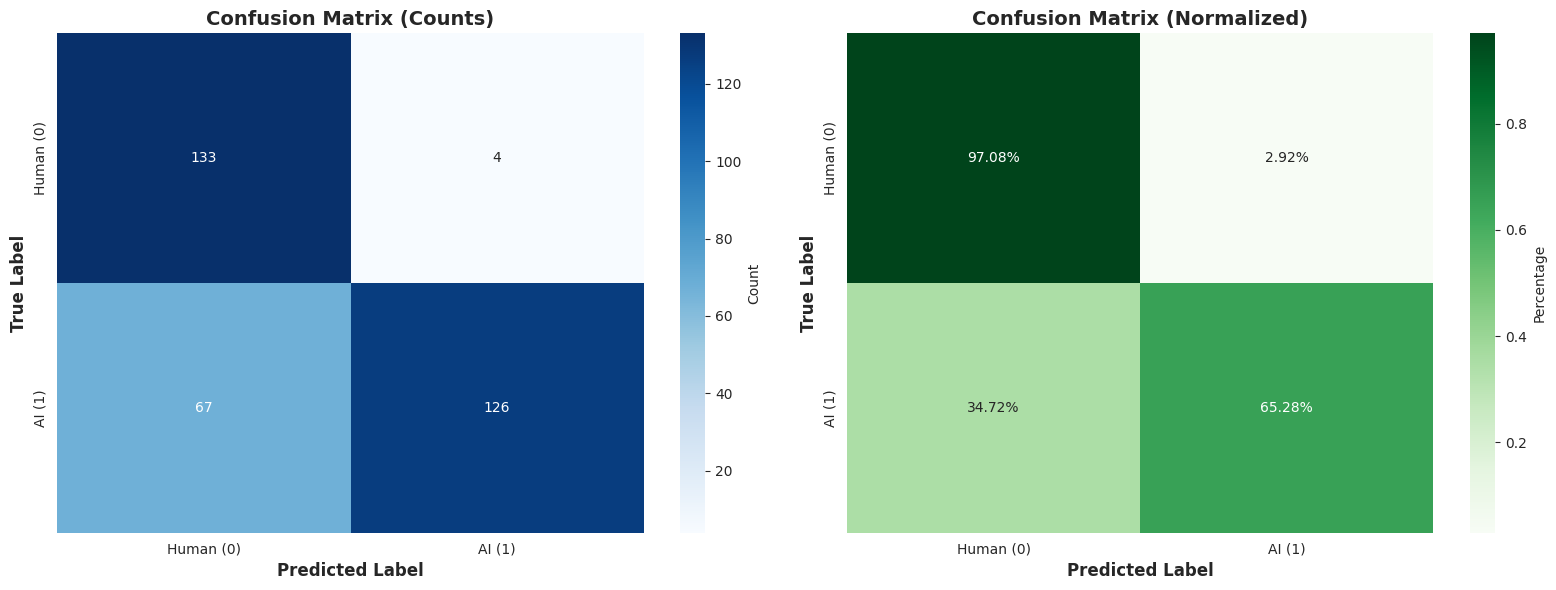

✓ Confusion matrices saved


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix (counts)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Human (0)', 'AI (1)'],
            yticklabels=['Human (0)', 'AI (1)'],
            cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Confusion matrix (normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['Human (0)', 'AI (1)'],
            yticklabels=['Human (0)', 'AI (1)'],
            cbar_kws={'label': 'Percentage'})
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(EVALUATION_OUTPUT_DIR, "confusion_matrices.png"), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrices saved")

## 13. Visualization: ROC Curve

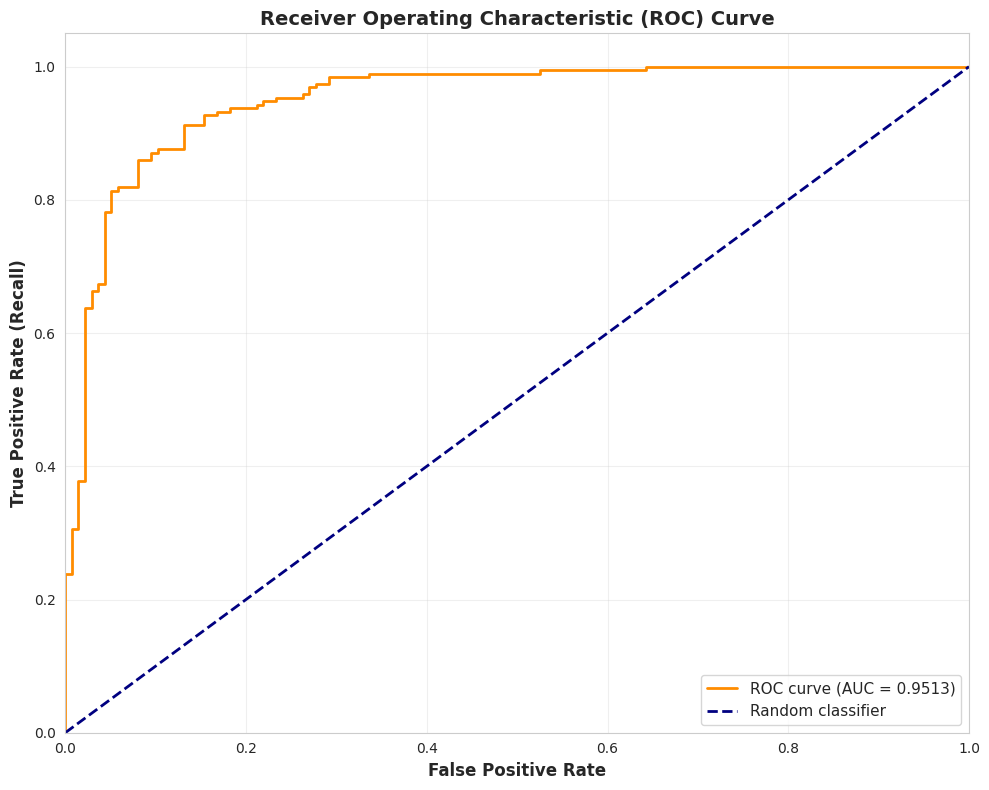

✓ ROC curve saved


In [13]:
plt.figure(figsize=(10, 8))

plt.plot(fpr_roc, tpr_roc, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Recall)', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(EVALUATION_OUTPUT_DIR, "roc_curve.png"), dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC curve saved")

## 14. Visualization: Precision-Recall Curve

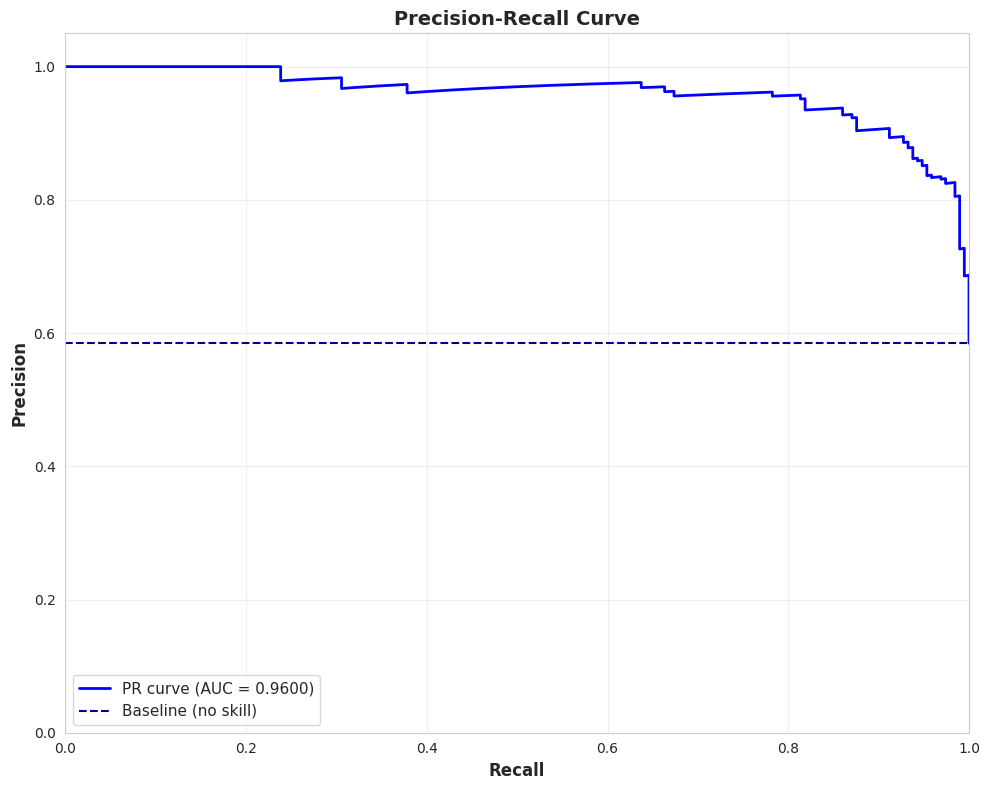

✓ Precision-Recall curve saved


In [14]:
precision_curve, recall_curve, thresholds = precision_recall_curve(all_true, all_probs)

plt.figure(figsize=(10, 8))

plt.plot(recall_curve, precision_curve, color='blue', lw=2,
         label=f'PR curve (AUC = {pr_auc:.4f})')
plt.axhline(y=(all_true == 1).sum() / len(all_true), color='navy', linestyle='--',
            label='Baseline (no skill)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(EVALUATION_OUTPUT_DIR, "precision_recall_curve.png"), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Precision-Recall curve saved")

## 15. Visualization: Probability Distribution

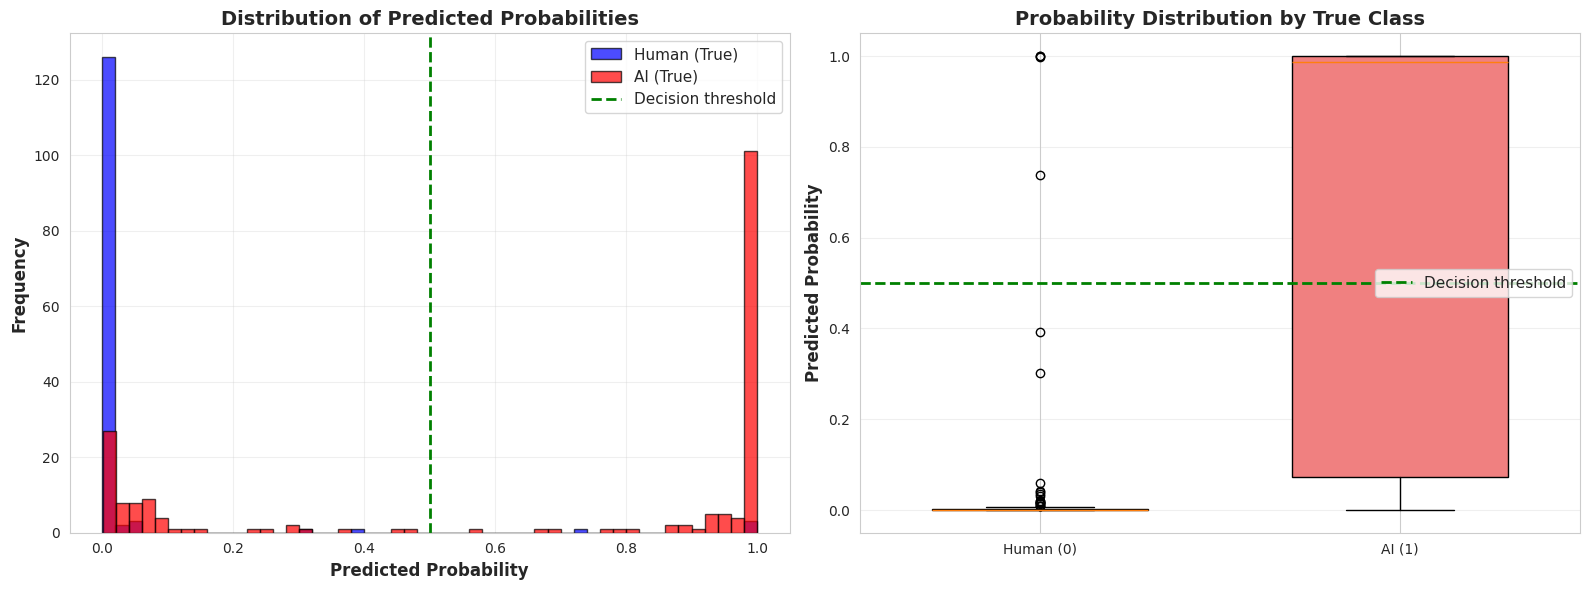

✓ Probability distributions saved


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of predicted probabilities
axes[0].hist(all_probs[all_true == 0], bins=50, alpha=0.7, label='Human (True)', color='blue', edgecolor='black')
axes[0].hist(all_probs[all_true == 1], bins=50, alpha=0.7, label='AI (True)', color='red', edgecolor='black')
axes[0].axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Decision threshold')
axes[0].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Box plot of predicted probabilities
prob_data = [
    all_probs[all_true == 0],
    all_probs[all_true == 1]
]
bp = axes[1].boxplot(prob_data, labels=['Human (0)', 'AI (1)'],
                      patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1].axhline(y=0.5, color='green', linestyle='--', linewidth=2, label='Decision threshold')
axes[1].set_ylabel('Predicted Probability', fontsize=12, fontweight='bold')
axes[1].set_title('Probability Distribution by True Class', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(EVALUATION_OUTPUT_DIR, "probability_distributions.png"), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Probability distributions saved")

## 16. Class-wise Performance Analysis


CLASS-WISE PERFORMANCE
    Class Precision Recall F1-Score  Support
Human (0)    66.50% 97.08%   78.93%      137
   AI (1)    96.92% 65.28%   78.02%      193


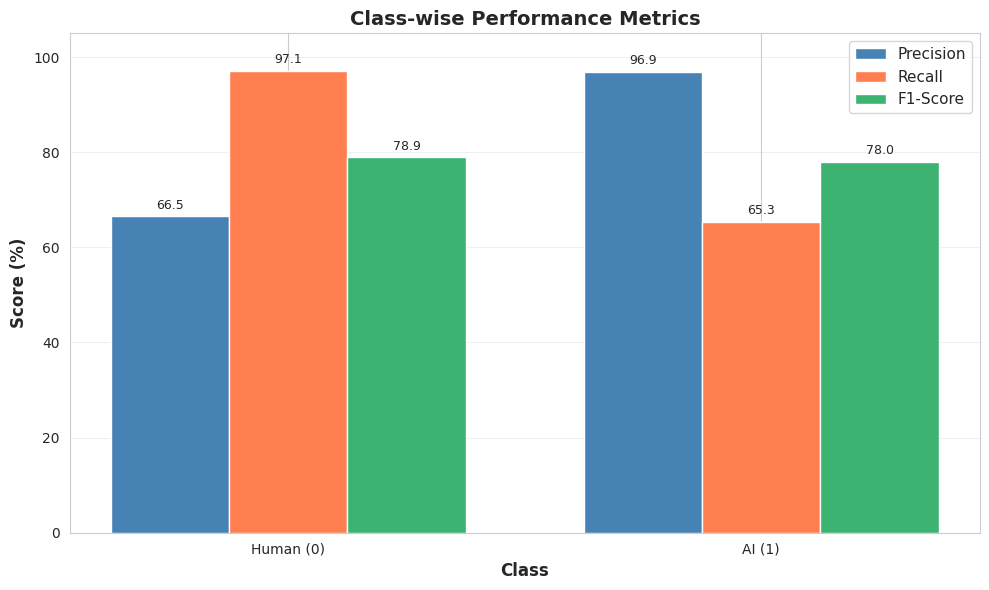

✓ Class-wise performance visualization saved


In [16]:
# Get per-class metrics
precision_per_class, recall_per_class, f1_per_class, support_per_class = \
    precision_recall_fscore_support(all_true, all_preds, average=None, zero_division=0)

# Create DataFrame
class_metrics = pd.DataFrame({
    'Class': ['Human (0)', 'AI (1)'],
    'Precision': [f"{p*100:.2f}%" for p in precision_per_class],
    'Recall': [f"{r*100:.2f}%" for r in recall_per_class],
    'F1-Score': [f"{f*100:.2f}%" for f in f1_per_class],
    'Support': support_per_class.astype(int)
})

print("\n" + "="*70)
print("CLASS-WISE PERFORMANCE")
print("="*70)
print(class_metrics.to_string(index=False))
print("="*70)

# Visualize class-wise metrics
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(class_metrics))
width = 0.25

precision_vals = [float(p.strip('%')) for p in class_metrics['Precision']]
recall_vals = [float(r.strip('%')) for r in class_metrics['Recall']]
f1_vals = [float(f.strip('%')) for f in class_metrics['F1-Score']]

ax.bar(x - width, precision_vals, width, label='Precision', color='steelblue')
ax.bar(x, recall_vals, width, label='Recall', color='coral')
ax.bar(x + width, f1_vals, width, label='F1-Score', color='mediumseagreen')

ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
ax.set_title('Class-wise Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_metrics['Class'])
ax.legend(fontsize=11)
ax.set_ylim([0, 105])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (p, r, f) in enumerate(zip(precision_vals, recall_vals, f1_vals)):
    ax.text(i - width, p + 1, f'{p:.1f}', ha='center', va='bottom', fontsize=9)
    ax.text(i, r + 1, f'{r:.1f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width, f + 1, f'{f:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(EVALUATION_OUTPUT_DIR, "class_wise_performance.png"), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Class-wise performance visualization saved")

## 17. Error Analysis

In [17]:
# Identify misclassified samples
misclassified_indices = np.where(all_preds != all_true)[0]
false_positives = np.where((all_preds == 1) & (all_true == 0))[0]
false_negatives = np.where((all_preds == 0) & (all_true == 1))[0]

print("\n" + "="*70)
print("ERROR ANALYSIS")
print("="*70)
print(f"\nTotal misclassified: {len(misclassified_indices)} / {len(all_true)} ({len(misclassified_indices)/len(all_true)*100:.2f}%)")
print(f"\nFalse Positives (Human predicted as AI): {len(false_positives)}")
print(f"False Negatives (AI predicted as Human): {len(false_negatives)}")

# Analyze confidence of errors
if len(misclassified_indices) > 0:
    error_probs = all_probs[misclassified_indices]
    error_confidences = np.abs(error_probs - 0.5)  # Distance from decision boundary

    print(f"\nError Confidence Analysis:")
    print(f"  Mean confidence: {error_confidences.mean():.4f}")
    print(f"  Median confidence: {np.median(error_confidences):.4f}")
    print(f"  High-confidence errors (>0.3): {(error_confidences > 0.3).sum()} ({(error_confidences > 0.3).sum()/len(error_confidences)*100:.1f}%)")

# Show examples of misclassified samples
print(f"\n{'─'*70}")
print("Sample Misclassifications (First 10):")
print(f"{'─'*70}")
print(f"{'Index':<8} {'True':<10} {'Predicted':<12} {'Probability':<12} {'Confidence'}")
print(f"{'─'*70}")

for idx in misclassified_indices[:10]:
    true_label = "Human (0)" if all_true[idx] == 0 else "AI (1)"
    pred_label = "Human (0)" if all_preds[idx] == 0 else "AI (1)"
    prob = all_probs[idx]
    conf = abs(prob - 0.5)
    print(f"{idx:<8} {true_label:<10} {pred_label:<12} {prob:<12.4f} {conf:.4f}")

print("="*70)


ERROR ANALYSIS

Total misclassified: 71 / 330 (21.52%)

False Positives (Human predicted as AI): 4
False Negatives (AI predicted as Human): 67

Error Confidence Analysis:
  Mean confidence: 0.4281
  Median confidence: 0.4704
  High-confidence errors (>0.3): 62 (87.3%)

──────────────────────────────────────────────────────────────────────
Sample Misclassifications (First 10):
──────────────────────────────────────────────────────────────────────
Index    True       Predicted    Probability  Confidence
──────────────────────────────────────────────────────────────────────
1        AI (1)     Human (0)    0.0060       0.4940
2        AI (1)     Human (0)    0.0037       0.4963
5        AI (1)     Human (0)    0.0019       0.4981
10       AI (1)     Human (0)    0.0244       0.4756
11       AI (1)     Human (0)    0.1050       0.3950
13       Human (0)  AI (1)       0.9970       0.4970
16       AI (1)     Human (0)    0.0018       0.4982
18       AI (1)     Human (0)    0.0410       0.45

## 18. Threshold Analysis

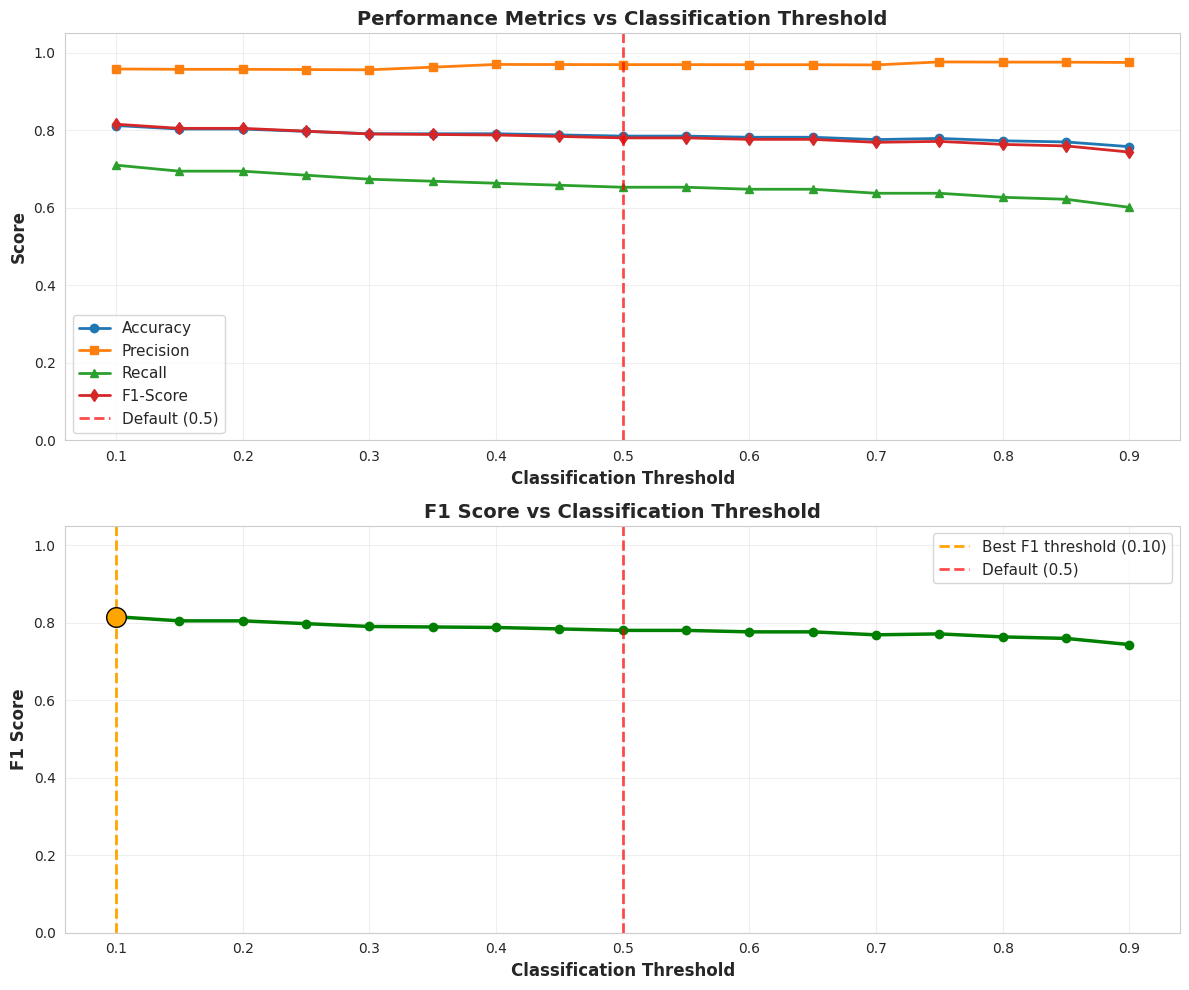


✓ Threshold analysis saved

Optimal threshold for F1: 0.10 (F1 = 0.8155)


In [18]:
# Analyze performance at different thresholds
thresholds_to_test = np.arange(0.1, 0.91, 0.05)
threshold_results = []

for thresh in thresholds_to_test:
    preds_at_thresh = (all_probs > thresh).astype(int)
    acc = accuracy_score(all_true, preds_at_thresh)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_true, preds_at_thresh, average='binary', zero_division=0
    )
    threshold_results.append({
        'threshold': thresh,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    })

threshold_df = pd.DataFrame(threshold_results)

# Plot threshold analysis
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Metrics vs threshold
axes[0].plot(threshold_df['threshold'], threshold_df['accuracy'], marker='o', label='Accuracy', linewidth=2)
axes[0].plot(threshold_df['threshold'], threshold_df['precision'], marker='s', label='Precision', linewidth=2)
axes[0].plot(threshold_df['threshold'], threshold_df['recall'], marker='^', label='Recall', linewidth=2)
axes[0].plot(threshold_df['threshold'], threshold_df['f1'], marker='d', label='F1-Score', linewidth=2)
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Default (0.5)')
axes[0].set_xlabel('Classification Threshold', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Performance Metrics vs Classification Threshold', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11, loc='best')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

# F1 score detail
axes[1].plot(threshold_df['threshold'], threshold_df['f1'], marker='o', color='green', linewidth=2.5)
best_f1_idx = threshold_df['f1'].idxmax()
best_f1_thresh = threshold_df.loc[best_f1_idx, 'threshold']
best_f1_score = threshold_df.loc[best_f1_idx, 'f1']
axes[1].axvline(x=best_f1_thresh, color='orange', linestyle='--', linewidth=2,
                label=f'Best F1 threshold ({best_f1_thresh:.2f})')
axes[1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Default (0.5)')
axes[1].scatter([best_f1_thresh], [best_f1_score], color='orange', s=200, zorder=5, edgecolor='black')
axes[1].set_xlabel('Classification Threshold', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1 Score', fontsize=12, fontweight='bold')
axes[1].set_title('F1 Score vs Classification Threshold', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11, loc='best')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(os.path.join(EVALUATION_OUTPUT_DIR, "threshold_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Threshold analysis saved")
print(f"\nOptimal threshold for F1: {best_f1_thresh:.2f} (F1 = {best_f1_score:.4f})")

## 19. Save All Metrics to JSON

In [19]:
evaluation_results = {
    "model_info": {
        "training_dir": TRAINING_RESULTS_DIR,
        "embeddings_dir": EMBEDDINGS_DIR,
        "model_architecture": "Bidirectional LSTM with Attention",
        "actual_embedding_dim": actual_embedding_dim,
        "checkpoint_embedding_dim": checkpoint.get('embedding_dim', 'N/A'),
        "hidden_dim": checkpoint.get('hidden_dim', 'N/A'),
        "num_layers": checkpoint.get('num_layers', 'N/A'),
        "dropout": checkpoint['dropout'],
        "trained_epoch": checkpoint['epoch'] + 1,
        "validation_accuracy": float(checkpoint['val_acc'])
    },
    "test_set_info": {
        "total_samples": int(len(all_true)),
        "human_samples": int((all_true == 0).sum()),
        "ai_samples": int((all_true == 1).sum())
    },
    "classification_metrics": {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "f1_score": float(f1),
        "npv": float(npv)
    },
    "advanced_metrics": {
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "matthews_correlation_coefficient": float(mcc),
        "cohens_kappa": float(kappa)
    },
    "error_rates": {
        "false_positive_rate": float(fpr),
        "false_negative_rate": float(fnr)
    },
    "confusion_matrix": {
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp)
    },
    "confidence_intervals_95": {
        "accuracy": {
            "mean": float(acc_mean),
            "lower": float(acc_lower),
            "upper": float(acc_upper)
        },
        "f1_score": {
            "mean": float(f1_mean),
            "lower": float(f1_lower),
            "upper": float(f1_upper)
        }
    },
    "class_wise_metrics": {
        "human": {
            "precision": float(precision_per_class[0]),
            "recall": float(recall_per_class[0]),
            "f1_score": float(f1_per_class[0]),
            "support": int(support_per_class[0])
        },
        "ai": {
            "precision": float(precision_per_class[1]),
            "recall": float(recall_per_class[1]),
            "f1_score": float(f1_per_class[1]),
            "support": int(support_per_class[1])
        }
    },
    "error_analysis": {
        "total_misclassified": int(len(misclassified_indices)),
        "false_positives": int(len(false_positives)),
        "false_negatives": int(len(false_negatives))
    },
    "optimal_threshold": {
        "threshold": float(best_f1_thresh),
        "f1_score": float(best_f1_score)
    },
    "evaluation_timestamp": datetime.now().isoformat()
}

# Save to JSON
with open(os.path.join(EVALUATION_OUTPUT_DIR, "evaluation_results.json"), "w") as f:
    json.dump(evaluation_results, f, indent=2)

print("\n✓ Evaluation results saved to JSON")


✓ Evaluation results saved to JSON


## 20. Generate Detailed Classification Report

In [20]:
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
print()
print(classification_report(all_true, all_preds, target_names=['Human (0)', 'AI (1)'], digits=4))
print("="*70)

# Save to text file
with open(os.path.join(EVALUATION_OUTPUT_DIR, "classification_report.txt"), "w") as f:
    f.write("="*70 + "\n")
    f.write("DETAILED CLASSIFICATION REPORT\n")
    f.write("="*70 + "\n\n")
    f.write(classification_report(all_true, all_preds, target_names=['Human (0)', 'AI (1)'], digits=4))
    f.write("\n" + "="*70)

print("\n✓ Classification report saved to text file")


DETAILED CLASSIFICATION REPORT

              precision    recall  f1-score   support

   Human (0)     0.6650    0.9708    0.7893       137
      AI (1)     0.9692    0.6528    0.7802       193

    accuracy                         0.7848       330
   macro avg     0.8171    0.8118    0.7848       330
weighted avg     0.8429    0.7848    0.7840       330


✓ Classification report saved to text file


## 21. Create Comprehensive Summary Dashboard

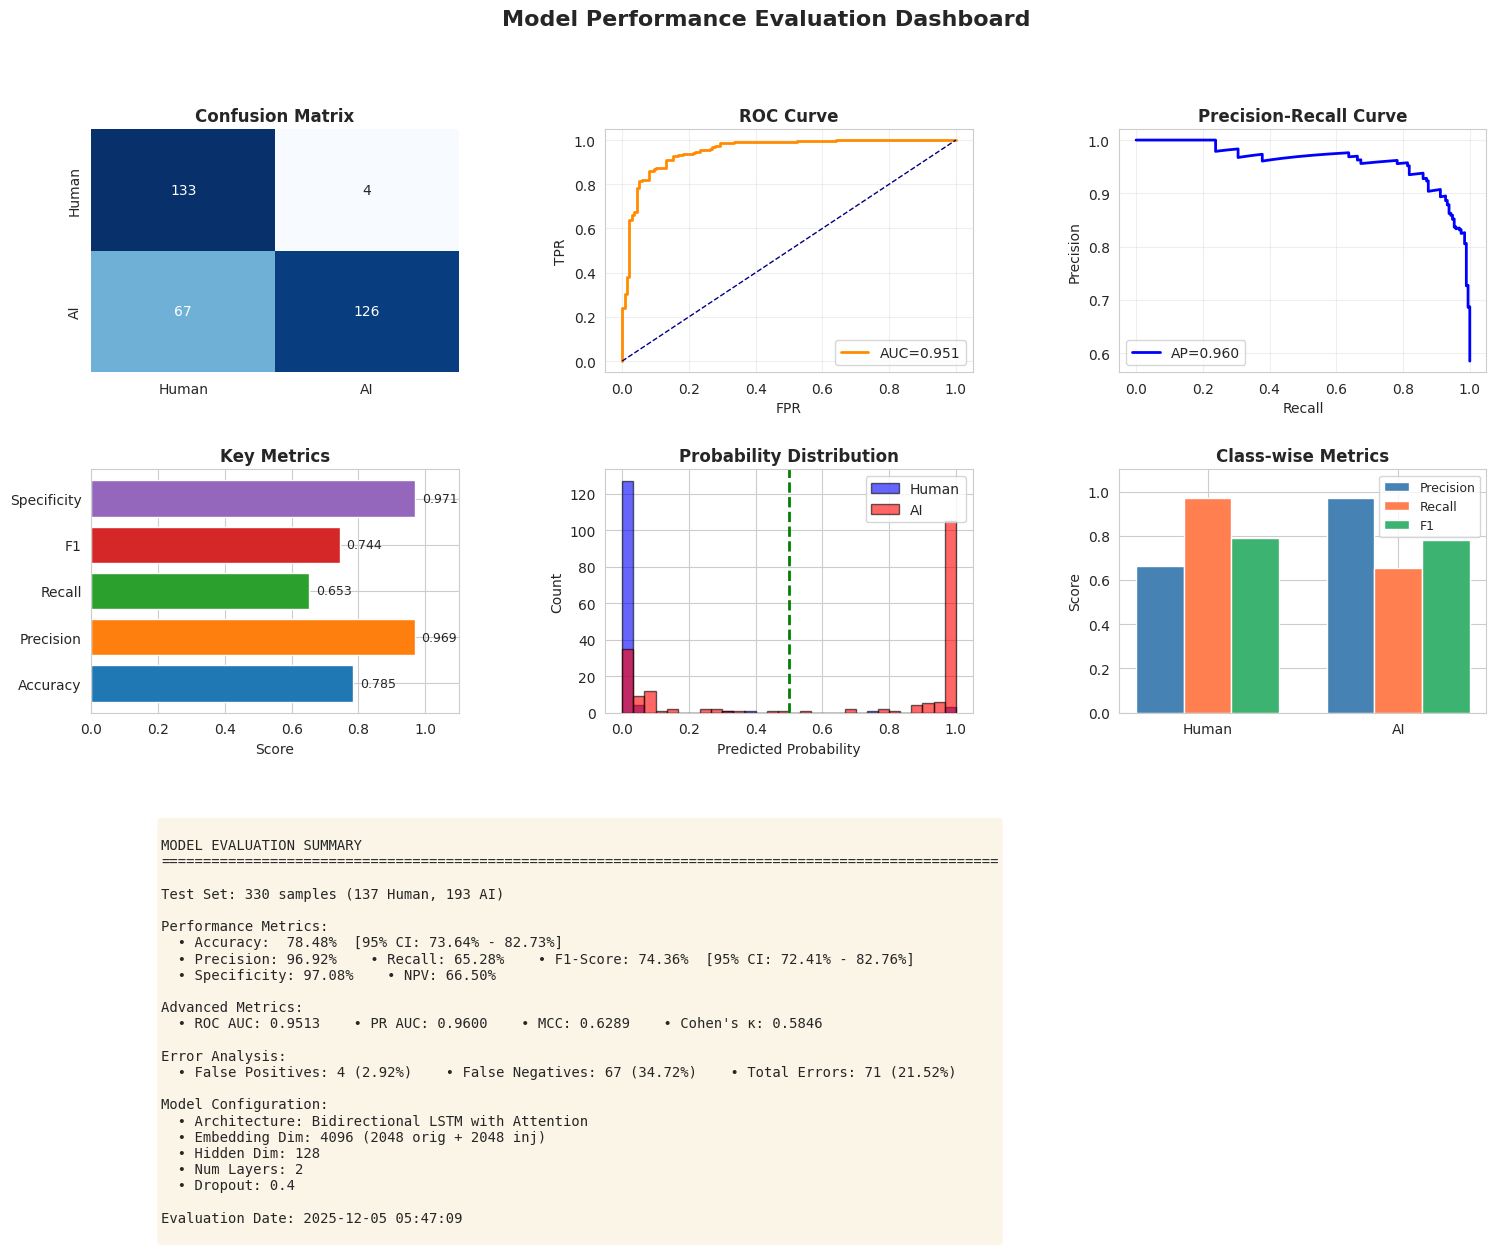


✓ Evaluation dashboard saved


In [21]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.4)

# 1. Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'], cbar=False)
ax1.set_title('Confusion Matrix', fontweight='bold')

# 2. ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(fpr_roc, tpr_roc, color='darkorange', lw=2, label=f'AUC={roc_auc:.3f}')
ax2.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
ax2.set_xlabel('FPR')
ax2.set_ylabel('TPR')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# 3. PR Curve
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(recall_curve, precision_curve, color='blue', lw=2, label=f'AP={pr_auc:.3f}')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve', fontweight='bold')
ax3.legend(loc='lower left')
ax3.grid(True, alpha=0.3)

# 4. Metrics Bar Chart
ax4 = fig.add_subplot(gs[1, 0])
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'Specificity']
metrics_values = [accuracy, precision, recall, f1, specificity]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = ax4.barh(metrics_names, metrics_values, color=colors)
ax4.set_xlim([0, 1.1])
ax4.set_xlabel('Score')
ax4.set_title('Key Metrics', fontweight='bold')
for i, (bar, val) in enumerate(zip(bars, metrics_values)):
    ax4.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9)

# 5. Probability Distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(all_probs[all_true == 0], bins=30, alpha=0.6, label='Human', color='blue', edgecolor='black')
ax5.hist(all_probs[all_true == 1], bins=30, alpha=0.6, label='AI', color='red', edgecolor='black')
ax5.axvline(x=0.5, color='green', linestyle='--', linewidth=2)
ax5.set_xlabel('Predicted Probability')
ax5.set_ylabel('Count')
ax5.set_title('Probability Distribution', fontweight='bold')
ax5.legend()

# 6. Class-wise Performance
ax6 = fig.add_subplot(gs[1, 2])
x_pos = np.arange(2)
width = 0.25
ax6.bar(x_pos - width, [precision_per_class[0], precision_per_class[1]], width, label='Precision', color='steelblue')
ax6.bar(x_pos, [recall_per_class[0], recall_per_class[1]], width, label='Recall', color='coral')
ax6.bar(x_pos + width, [f1_per_class[0], f1_per_class[1]], width, label='F1', color='mediumseagreen')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(['Human', 'AI'])
ax6.set_ylabel('Score')
ax6.set_title('Class-wise Metrics', fontweight='bold')
ax6.legend(fontsize=9)
ax6.set_ylim([0, 1.1])

# 7. Summary Text
ax7 = fig.add_subplot(gs[2, :])
ax7.axis('off')
summary_text = f"""
MODEL EVALUATION SUMMARY
{'='*100}

Test Set: {len(all_true)} samples ({(all_true==0).sum()} Human, {(all_true==1).sum()} AI)

Performance Metrics:
  • Accuracy:  {accuracy*100:.2f}%  [95% CI: {acc_lower*100:.2f}% - {acc_upper*100:.2f}%]
  • Precision: {precision*100:.2f}%    • Recall: {recall*100:.2f}%    • F1-Score: {f1*100:.2f}%  [95% CI: {f1_lower*100:.2f}% - {f1_upper*100:.2f}%]
  • Specificity: {specificity*100:.2f}%    • NPV: {npv*100:.2f}%

Advanced Metrics:
  • ROC AUC: {roc_auc:.4f}    • PR AUC: {pr_auc:.4f}    • MCC: {mcc:.4f}    • Cohen's κ: {kappa:.4f}

Error Analysis:
  • False Positives: {fp} ({fpr*100:.2f}%)    • False Negatives: {fn} ({fnr*100:.2f}%)    • Total Errors: {len(misclassified_indices)} ({len(misclassified_indices)/len(all_true)*100:.2f}%)

Model Configuration:
  • Architecture: Bidirectional LSTM with Attention
  • Embedding Dim: {actual_embedding_dim} (2048 orig + 2048 inj)
  • Hidden Dim: {checkpoint.get('hidden_dim', 'N/A')}
  • Num Layers: {checkpoint.get('num_layers', 'N/A')}
  • Dropout: {checkpoint['dropout']}

Evaluation Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

ax7.text(0.05, 0.95, summary_text, transform=ax7.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Model Performance Evaluation Dashboard', fontsize=16, fontweight='bold', y=0.98)
plt.savefig(os.path.join(EVALUATION_OUTPUT_DIR, "evaluation_dashboard.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Evaluation dashboard saved")

## 22. Final Summary

In [22]:
print("\n" + "="*70)
print("EVALUATION COMPLETE - SUMMARY")
print("="*70)
print(f"\n✓ All evaluation results saved to Google Drive:")
print(f"  {EVALUATION_OUTPUT_DIR}\n")
print(f"Generated Files:")
print(f"  1. evaluation_results.json - Complete metrics in JSON format")
print(f"  2. confusion_matrices.png - Count & normalized confusion matrices")
print(f"  3. roc_curve.png - ROC curve with AUC")
print(f"  4. precision_recall_curve.png - PR curve with AUC")
print(f"  5. probability_distributions.png - Probability histograms & boxplots")
print(f"  6. class_wise_performance.png - Per-class metrics visualization")
print(f"  7. threshold_analysis.png - Performance vs threshold")
print(f"  8. classification_report.txt - Detailed text report")
print(f"  9. evaluation_dashboard.png - Comprehensive summary dashboard\n")
print(f"Key Results:")
print(f"  📊 Accuracy:     {accuracy*100:.2f}% [{acc_lower*100:.2f}% - {acc_upper*100:.2f}%]")
print(f"  📊 Precision:    {precision*100:.2f}%")
print(f"  📊 Recall:       {recall*100:.2f}%")
print(f"  📊 F1-Score:     {f1*100:.2f}% [{f1_lower*100:.2f}% - {f1_upper*100:.2f}%]")
print(f"  📊 ROC AUC:      {roc_auc:.4f}")
print(f"  📊 PR AUC:       {pr_auc:.4f}")
print(f"\n  ❌ Error Rate:   {len(misclassified_indices)/len(all_true)*100:.2f}% ({len(misclassified_indices)}/{len(all_true)})")
print(f"  ❌ FP Rate:      {fpr*100:.2f}% ({fp} samples)")
print(f"  ❌ FN Rate:      {fnr*100:.2f}% ({fn} samples)")
print("\n" + "="*70)
print("🎉 Evaluation completed successfully!")
print("="*70)


EVALUATION COMPLETE - SUMMARY

✓ All evaluation results saved to Google Drive:
  /content/drive/MyDrive/HC3_Model_Evaluation/20251205_054641

Generated Files:
  1. evaluation_results.json - Complete metrics in JSON format
  2. confusion_matrices.png - Count & normalized confusion matrices
  3. roc_curve.png - ROC curve with AUC
  4. precision_recall_curve.png - PR curve with AUC
  5. probability_distributions.png - Probability histograms & boxplots
  6. class_wise_performance.png - Per-class metrics visualization
  7. threshold_analysis.png - Performance vs threshold
  8. classification_report.txt - Detailed text report
  9. evaluation_dashboard.png - Comprehensive summary dashboard

Key Results:
  📊 Accuracy:     78.48% [73.64% - 82.73%]
  📊 Precision:    96.92%
  📊 Recall:       65.28%
  📊 F1-Score:     74.36% [72.41% - 82.76%]
  📊 ROC AUC:      0.9513
  📊 PR AUC:       0.9600

  ❌ Error Rate:   21.52% (71/330)
  ❌ FP Rate:      2.92% (4 samples)
  ❌ FN Rate:      34.72% (67 samples